# Causal Inference for Digital Ad Measurement
This project benchmarks observational methods, specifically Inverse Probability Weighting (IPW) and Double Machine Learning (Double ML), against a Randomized Controlled Trial (RCT) ground truth to evaluate whether experiments can be replaced by cheaper observational approaches in digital advertising. Data covers 2M users with behavioral features, experimental treatment (Z), ad exposure indicator (W), and a binary conversion outcome (Y).

## 1. Data Loading and Preparation
The dataset contains 2,000,000 rows and 12 columns. Key indicator columns are renamed for readability: Z to treatment, W to exposed, and Y to converted. The crosstab below confirms that the Ghost Ads methodology produces a nearly identical exposure distribution across treatment and control groups, which is expected by design.

In [1]:
import pandas as pd

df = pd.read_csv('advertising_data.csv')
print(df.shape)
display(df.head())

(2000000, 12)


,age,gender,activity,num_friends,time_on_platform,mobile_frac,prior_conversion,income,urban_index,Z,W,Y
0,56,1,0.724570,852,953.588845,0.711859,0.443672,51554.675281,0.123847,1,1,0
1,69,1,0.187800,768,763.591158,0.945347,0.682151,79613.106338,0.825017,1,1,1
2,46,1,0.112749,152,2092.389941,0.285945,0.813846,92714.915330,0.961640,0,1,0
3,32,1,0.027889,498,530.571433,0.103701,0.523944,154977.093058,0.694678,0,0,0
4,60,1,0.913549,604,2158.984762,0.999327,0.965953,192350.688785,0.834792,0,1,0


In [2]:
df.rename(columns={'Z' : 'treatment'}, inplace=True)
df.rename(columns={'W' : 'exposed'}, inplace=True)
df.rename(columns={'Y' : 'converted'}, inplace=True)

pd.crosstab(df['treatment'], df['exposed'])

exposed,0,1
treatment,,
0,171131,827327
1,171688,829854


## 2. Randomization Check
Before estimating any treatment effects, we verify that randomization was successful. A logistic regression predicting treatment assignment from key covariates (prior conversion rate, platform activity, and income) should yield coefficients that are statistically indistinguishable from zero if the groups are balanced.

In [3]:
import statsmodels.formula.api as smf

rand_check_model = smf.logit(formula='treatment ~ prior_conversion + activity + income', data=df).fit()
print(rand_check_model.summary())

Optimization terminated successfully.
         Current function value: 0.693146
         Iterations 2
                           Logit Regression Results                           
Dep. Variable:              treatment   No. Observations:              2000000
Model:                          Logit   Df Residuals:                  1999996
Method:                           MLE   Df Model:                            3
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:               2.089e-08
Time:                        01:34:38   Log-Likelihood:            -1.3863e+06
converged:                       True   LL-Null:                   -1.3863e+06
Covariance Type:            nonrobust   LLR p-value:                    0.9964
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.0021      0.005      0.423      0.673      -0.008       0.012
prior_conve

All three coefficients are near zero with p-values well above 0.05, and the pseudo R-squared is essentially 0. Randomization holds; covariates have no meaningful predictive power over treatment assignment.

## 3. Experimental Benchmarks: ATT and ITT
Using the full experimental data, we establish the ground truth estimates that all subsequent observational methods will be measured against. The dataset is split into treatment and control groups, and within the treatment group, further split by actual ad exposure.

In [4]:
df_treatment = df[df['treatment'] == 1].copy()
df_control = df[df['treatment'] == 0].copy()

df_treatment_exposed = df_treatment[df_treatment['exposed'] == 1]
df_control_exposed = df_control[df_control['exposed'] == 1]

In [5]:
print("ATT absolute lift:", df_treatment_exposed['converted'].mean() - df_control_exposed['converted'].mean())
print("ATT relative lift:", (df_treatment_exposed['converted'].mean() - df_control_exposed['converted'].mean()) / df_control_exposed['converted'].mean())

ATT absolute lift: 0.05579494115261796
ATT relative lift: 0.2623897892213226


In [6]:
print("ITT absolute lift:", df_treatment['converted'].mean() - df_control['converted'].mean())
print("ITT relative lift:", (df_treatment['converted'].mean() - df_control['converted'].mean()) / df_control['converted'].mean())

ITT absolute lift: 0.04639635652358626
ITT relative lift: 0.23843741586754966


The experimental ATT is approximately 5.6 percentage points (roughly 26% relative lift), representing the causal effect of ad exposure on users who were actually exposed. The ITT of about 4.6 percentage points is lower, as expected, since it averages over both exposed and unexposed users in the treatment group. These two estimates serve as the ground truth benchmark for evaluating the observational methods below.



## 4. Naive Comparison
As a baseline, we compare conversion rates between exposed and unexposed users within the treatment group only, ignoring any covariate differences between the two groups. This mimics the situation a practitioner would face with no RCT and no adjustment strategy.

In [7]:
print("Naive absolute lift is:", df_treatment[df_treatment['exposed'] == 1]['converted'].mean() - df_treatment[df_treatment['exposed'] == 0]['converted'].mean())
print("Naive relative lift is:", (df_treatment[df_treatment['exposed'] == 1]['converted'].mean() - df_treatment[df_treatment['exposed'] == 0]['converted'].mean()) / df_treatment[df_treatment['exposed'] == 0]['converted'].mean())


Naive absolute lift is: 0.16015856930201466
Naive relative lift is: 1.4791449406306774


The naive estimate produces an absolute lift of roughly 16 percentage points and a relative lift of approximately 148%, far exceeding the experimental ground truth. This overstatement is likely driven by activity bias: users who were exposed to the ad tend to be more active on the platform, and more active users may convert at higher rates regardless of ad exposure. Without any adjustment for these differences, the naive comparison likely conflates the effect of the ad with the effect of being a highly active user.

## 5. Regression Adjustment
As a first attempt at correcting for confounding, we fit three logistic regression models of conversion on ad exposure within the treatment group: an unadjusted baseline, a partial model controlling for platform activity, and a fuller model including all available covariates. We use the fuller model to estimate lift by predicting each user's conversion probability under their actual exposure, then re-predicting under a counterfactual where exposure is set to zero for everyone, and averaging the difference across originally exposed users.

In [8]:
# Unadjusted baseline regression
model_reg = smf.logit(formula='converted ~ exposed', data=df_treatment).fit()
print(model_reg.summary())

Optimization terminated successfully.
         Current function value: 0.540762
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:              1001542
Model:                          Logit   Df Residuals:                  1001540
Method:                           MLE   Df Model:                            1
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                 0.02073
Time:                        01:34:45   Log-Likelihood:            -5.4160e+05
converged:                       True   LL-Null:                   -5.5306e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.1085      0.008   -271.468      0.000      -2.124      -2.093
exposed        1.1059      0.

In [9]:
new_obs_exposed = pd.DataFrame({'exposed': [1]})
new_obs_non_exposed = pd.DataFrame({'exposed': [0]})

pred_exposed = model_reg.predict(new_obs_exposed)
pred_non_exposed = model_reg.predict(new_obs_non_exposed)

print(f"Absolute lift from regression (unadjusted): {(pred_exposed - pred_non_exposed).values[0]:.4f}")
print(f"Relative lift from regression (unadjusted): {((pred_exposed - pred_non_exposed) / pred_non_exposed).values[0]:.4f}")

Absolute lift from regression (unadjusted): 0.1602
Relative lift from regression (unadjusted): 1.4791


In [10]:
# Partial model regression
model_adj_reg = smf.logit(formula='converted ~ exposed + activity', data=df_treatment).fit()
print(model_adj_reg.summary())

Optimization terminated successfully.
         Current function value: 0.520680
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:              1001542
Model:                          Logit   Df Residuals:                  1001539
Method:                           MLE   Df Model:                            2
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                 0.05710
Time:                        01:34:50   Log-Likelihood:            -5.2148e+05
converged:                       True   LL-Null:                   -5.5306e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.7609      0.009   -316.993      0.000      -2.778      -2.744
exposed        0.7704      0.

In [11]:
# Fuller model regression
model_adj_reg2 = smf.logit(formula='converted ~ exposed + activity + age + gender + num_friends + time_on_platform + mobile_frac + prior_conversion + income + urban_index', data=df_treatment).fit()
print(model_adj_reg2.summary())

Optimization terminated successfully.
         Current function value: 0.514324
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:              1001542
Model:                          Logit   Df Residuals:                  1001531
Method:                           MLE   Df Model:                           10
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                 0.06860
Time:                        01:34:59   Log-Likelihood:            -5.1512e+05
converged:                       True   LL-Null:                   -5.5306e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -3.5724      0.017   -212.491      0.000      -3.605      -3.539
exposed    

In [12]:
# Predict conversion probability for exposed users under actual exposure
df_exposed = df_treatment[df_treatment['exposed'] == 1].copy()
df_exposed['predicted_converted'] = model_adj_reg2.predict(df_exposed)
mean_pred_with_ad = df_exposed['predicted_converted'].mean()
print(f"Mean predicted conversion (with ad): {mean_pred_with_ad:.4f}")

Mean predicted conversion (with ad): 0.2684


In [13]:
# Predict counterfactual conversion probability with exposure set to zero
df_exposed['exposed'] = 0
df_exposed['predicted_converted_without_ads'] = model_adj_reg2.predict(df_exposed)
mean_pred_without_ad = df_exposed['predicted_converted_without_ads'].mean()
print(f"Mean predicted conversion (without ad): {mean_pred_without_ad:.4f}")

Mean predicted conversion (without ad): 0.1504


In [14]:
lift_abs_AR2 = mean_pred_with_ad - mean_pred_without_ad
lift_rel_AR2 = lift_abs_AR2 / mean_pred_without_ad

print(f"Adjusted regression absolute lift: {lift_abs_AR2:.4f}")
print(f"Adjusted regression relative lift: {lift_rel_AR2:.4f}")

Adjusted regression absolute lift: 0.1180
Adjusted regression relative lift: 0.7849


The unadjusted baseline yields an exposure coefficient of 1.11 and a lift estimate nearly identical to the naive comparison. Adding activity alone pulls the coefficient down to 0.77, confirming that platform activity is a major confounder, and the fuller specification brings little additional change. Applying the counterfactual prediction approach to the fuller model gives an absolute lift of roughly 11.8 percentage points (about 78% relative lift), a substantial reduction from the naive estimate but still far exceeding the experimental ground truth of 5.6 points. Regression adjustment meaningfully reduces bias compared to the naive approach but cannot eliminate it entirely, as the model cannot account for unobserved factors driving both exposure and conversion.

## 6. Inverse Probability Weighting (IPW)
IPW corrects for selection bias by reweighting observations based on their propensity score, the estimated probability of being exposed given observed covariates. We first fit a propensity score model on the treatment group, inspect the resulting score distributions to assess overlap between exposed and unexposed users, then apply ATT weights to estimate the causal effect of ad exposure.

In [15]:
ps_model = smf.logit(formula='exposed ~ activity + age + gender + num_friends + time_on_platform + mobile_frac + prior_conversion + income + urban_index', data=df_treatment).fit()
print(ps_model.summary())

Optimization terminated successfully.
         Current function value: 0.420031
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                exposed   No. Observations:              1001542
Model:                          Logit   Df Residuals:                  1001532
Method:                           MLE   Df Model:                            9
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                 0.08317
Time:                        01:35:07   Log-Likelihood:            -4.2068e+05
converged:                       True   LL-Null:                   -4.5884e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.0404      0.017      2.424      0.015       0.008       0.073
activity   

In [16]:
# Generate propensity scores for each user in the treatment group
df_treatment['ps'] = ps_model.predict(df_treatment)

In [17]:
df_treatment[['exposed', 'ps']].sample(10)

,exposed,ps
1468457,0,0.712867
326836,1,0.733480
1533265,1,0.941300
187257,1,0.628585
1057834,1,0.903866
1726827,0,0.862224
654347,1,0.760829
1189852,1,0.605614
611023,0,0.828751
1242379,1,0.881981


In [18]:
# Inspect propensity score distributions to assess overlap between exposed and unexposed users
df_treatment[df_treatment['exposed'] == 0][['exposed', 'ps']].sort_values(by='ps', ascending=False).head(20)

,exposed,ps
1425936,0,0.966201
1954356,0,0.964725
1720793,0,0.964372
9770,0,0.964307
1727181,0,0.964054
1914640,0,0.963841
437721,0,0.963541
576991,0,0.963532
1749364,0,0.963437
1942554,0,0.963423


In [19]:
df_treatment[df_treatment['exposed'] == 1][['exposed', 'ps']].sort_values(by='ps', ascending=False).head(10)

,exposed,ps
230649,1,0.967155
1611072,1,0.966695
789345,1,0.966673
973002,1,0.966618
779711,1,0.966354
1876441,1,0.966268
300255,1,0.966235
1871854,1,0.966117
566175,1,0.966052
139004,1,0.966040


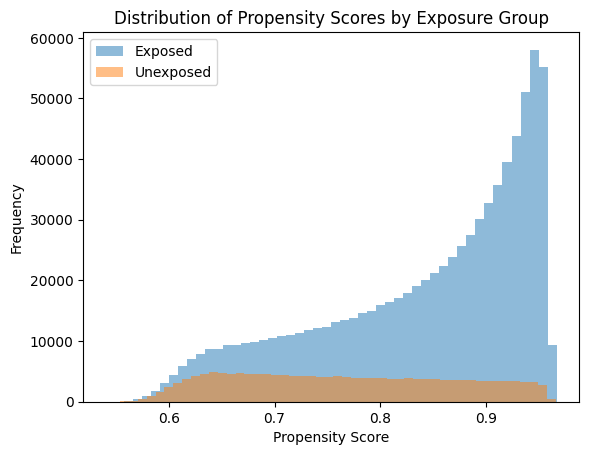

In [20]:
import matplotlib.pyplot as plt
plt.hist(df_treatment[df_treatment['exposed'] == 1]['ps'], bins=50, alpha=0.5, label='Exposed')
plt.hist(df_treatment[df_treatment['exposed'] == 0]['ps'], bins=50, alpha=0.5, label='Unexposed')
plt.xlabel('Propensity Score')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Propensity Scores by Exposure Group')
plt.show()

The propensity score model shows that platform activity is by far the strongest predictor of exposure, with a coefficient of 2.72. Comparing the score distributions between exposed and unexposed users reveals that many unexposed users have very high propensity scores, indicating they were behaviorally similar to exposed users but did not receive the ad. This confirms meaningful overlap between the two groups, which is a necessary condition for IPW to work.

In [21]:
import numpy as np
df_treatment['w_att'] = np.where(df_treatment['exposed'] == 1, 1, df_treatment['ps'] / (1 - df_treatment['ps']))

In [22]:
# Clipping was considered but not applied given the well-behaved weight distribution
# df_treatment['w_att'] = np.where(df_treatment['w_att'] >= cap, cap, df_treatment['w_att'])

In [23]:
df_treatment['w_att'].describe().apply(lambda x: f'{x:.4f}')

,w_att
count,1001542.0000
mean,1.6545
std,2.2505
min,1.0000
25%,1.0000
50%,1.0000
75%,1.0000
max,28.5870


In [24]:
mask_test = df_treatment['exposed'] == 1
mask_control = df_treatment['exposed'] == 0

exposed_mean = df_treatment[mask_test]['converted'].mean()
control_weighted_mean = (df_treatment[mask_control]['converted'] * df_treatment[mask_control]['w_att']).sum()/df_treatment[mask_control]['w_att'].sum()

print("ATT absolute lift:", exposed_mean - control_weighted_mean)
print("ATT relative lift:", (exposed_mean - control_weighted_mean) / control_weighted_mean)


ATT absolute lift: 0.11822816513541218
ATT relative lift: 0.7870952247216374


The IPW estimate produces an absolute lift of roughly 11.8 percentage points (about 79% relative lift), very close to the adjusted regression result but still well above the experimental ground truth of 5.6 points. The weight distribution shows a maximum weight of nearly 29, which could suggest extreme up-weighting of a small number of observations. However, the 75th percentile weight is 1.0 and the mean is only 1.65, indicating that the large maximum is driven by a very small tail of observations rather than a systematic problem. Given that the bulk of the weight distribution is well-behaved, clipping was not applied here.

## 7. Double Machine Learning (Double ML)
Double ML estimates the causal effect of ad exposure by using machine learning models to partial out the influence of covariates from both the outcome and the treatment, then relating the residuals to obtain a debiased estimate. Unlike regression adjustment and IPW, Double ML uses cross-fitting to avoid overfitting bias in the nuisance models, making it more robust to complex covariate relationships.

In [25]:
!pip install doubleml

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import doubleml as dml

In [26]:
# Define outcome, treatment, and covariate columns for the DoubleML data object
x_cols = ['age', 'gender', 'activity', 'num_friends', 'time_on_platform',
          'mobile_frac', 'prior_conversion', 'income', 'urban_index']

dml_data = dml.DoubleMLData(df_treatment, y_col='converted', d_cols='exposed', x_cols=x_cols)

In [27]:
# ml_g predicts the outcome (converted) from covariates
ml_g = RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42)

# ml_m predicts exposure from covariates, analogous to the propensity score model in IPW
ml_m = RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)

In [28]:
# Instantiate the Double ML IRM model targeting the ATT
dml_irm = dml.DoubleMLIRM(dml_data, ml_g, ml_m, score='ATTE')

# Fit the model using all available cores for cross-fitting
dml_irm.fit(n_jobs_cv=-1)

In [29]:
dml_irm.summary

,coef,std err,t,P>|t|,2.5 %,97.5 %
exposed,0.119441,0.001002,119.197038,0.0,0.117477,0.121405


In [30]:
baseline = df_treatment[df_treatment['exposed'] == 0]['converted'].mean()
dml_abs_lift = dml_irm.coef[0]
dml_rel_lift = dml_abs_lift / baseline

print(f"DML absolute lift: {dml_abs_lift:.4f}")
print(f"DML relative lift: {dml_rel_lift:.4f}")

DML absolute lift: 0.1194
DML relative lift: 1.1031


Double ML produces an absolute lift of approximately 11.9 percentage points, the closest among the observational methods to the adjusted regression and IPW results. Despite using flexible Random Forest models to partial out covariate effects, the estimate still substantially overstates the experimental ground truth of 5.6 points. This suggests that the remaining bias is driven by unobserved confounders, particularly the platform and auction dynamics that influence exposure but are not captured in the available covariates.

## 8. Conclusion
Across all four approaches, a consistent pattern emerges. While the three adjusted methods represent a substantial improvement over the naive estimate, all three still converge around 11 to 12 percentage points, roughly double the experimental ground truth. The naive comparison performs worst at 148% relative lift, driven almost entirely by activity bias. Regression adjustment, IPW, and Double ML all reduce this substantially by accounting for observed confounders, but none can close the remaining gap.
The persistence of bias across all three adjusted methods points to a common cause: unobserved factors such as platform targeting optimization and auction dynamics may influence both exposure and conversion in ways that no amount of covariate adjustment can fully address. This analysis illustrates both the value and the limits of observational causal inference in digital advertising, and underscores why randomized experiments remain the gold standard for measuring ad lift when the cost of doing so is justified.

## 9. Business Implications: Short-Term Gain vs. Measurement Quality

This section evaluates the tradeoff between running a randomized controlled trial and advertising to all eligible users immediately.

Running the experiment improves measurement quality by identifying a credible experimental ATT, but it also requires withholding ads from control users who otherwise may have converted. A no-experiment strategy could generate more short-term conversions by targeting everyone, but it would require relying on an observational estimate such as Double Machine Learning (DML), which may overstate the true effect.

To illustrate this tradeoff, I compare:
- incremental conversions realized under the RCT design
- estimated incremental conversions under a full-targeting strategy using the experimental ATT
- estimated incremental conversions under a full-targeting strategy using the DML ATT

In [31]:
# Key quantities for comparing experimental holdout versus full targeting
true_att = df_treatment_exposed['converted'].mean() - df_control_exposed['converted'].mean()
dml_att = dml_irm.coef[0]

n_exposed = df_treatment[df_treatment['exposed'] == 1].shape[0]
n_control_exposed = df_control[df_control['exposed'] == 1].shape[0]

In [32]:
# Incremental conversions realized during the experiment
incremental_conversions_rct = true_att * n_exposed

print(f"Incremental conversions under RCT design: {incremental_conversions_rct:.0f}")

Incremental conversions under RCT design: 46302


In [33]:
# Estimated incremental conversions if all eligible users had been targeted
incremental_conversions_full_targeting_true = true_att * (n_exposed + n_control_exposed)

# Short-term opportunity cost of running the RCT
foregone_conversions = incremental_conversions_full_targeting_true - incremental_conversions_rct

print(f"Estimated incremental conversions under full targeting (true ATT): {incremental_conversions_full_targeting_true:.0f}")
print(f"Estimated conversions foregone by holding out the control group: {foregone_conversions:.0f}")

Estimated incremental conversions under full targeting (true ATT): 92462
Estimated conversions foregone by holding out the control group: 46161


In [34]:
# Estimated incremental conversions under a no-RCT strategy using DML
incremental_conversions_full_targeting_dml = dml_att * (n_exposed + n_control_exposed)

print(f"Estimated incremental conversions under full targeting (DML ATT): {incremental_conversions_full_targeting_dml:.0f}")

Estimated incremental conversions under full targeting (DML ATT): 197935


In [35]:
# Potential overstatement in incremental conversions under the DML-based full-targeting approach
potential_overstatement_full_targeting = (
    incremental_conversions_full_targeting_dml - incremental_conversions_full_targeting_true
)

print(f"Potential overstatement under DML-based full targeting: {potential_overstatement_full_targeting:.0f}")

Potential overstatement under DML-based full targeting: 105473


## 9. Business Implications: Short-Term Gain vs. Measurement Quality

Had all eligible users been targeted, the campaign would have generated approximately 92,462 incremental conversions, which is 46,161 more than the conversions realized under the RCT design. However, relying on the DML estimate would have projected approximately 197,935 incremental conversions, overstating the true impact of advertising when applied to the full population.

This highlights the core tradeoff in measurement strategy. Running the experiment imposes a clear short-term cost by withholding ads from control users, but it provides an unbiased estimate of causal lift. In contrast, a no-experiment strategy preserves full targeting and maximizes short-term conversions, but risks overstating effectiveness and leading to suboptimal future budget decisions. This brings us to the key question: are the 46,161 additional short-term conversions worth the value of obtaining a reliable estimate of advertising effectiveness?

In practice, the answer depends on how heavily future decisions rely on accurate measurement. For large advertisers managing significant budgets, even small biases in lift estimation can lead to substantial misallocation of spend over time, increasing the value of experimentation. In some cases, the importance of this tradeoff may be reduced. For example, smaller campaigns or settings with stable and well-understood audiences may be less sensitive to bias in lift estimation. While this is not directly tested here, it highlights how the value of experimentation can vary across contexts.

In this context, experimentation can be viewed not as a cost, but as an investment in the quality of future decisions.